In [1]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4820
ROI_Y = 1710
ROI_W = 128
ROI_H = 256


In [2]:
import sys
import argparse
import logging
from pathlib import Path
import cv2
import numpy as np
import networkx as nx
from neural_reconstruction.ui.main_pipeline import NeuralReconstructionPipeline
from neural_reconstruction.core.preprocessing.config import (
    PipelineConfig as PreprocessingConfig,
)


In [3]:
base_path = f"../data/{IMAGE_ID}/"

orig_img = cv2.imread(f"{base_path}/image.png")[:, :, 1]
mask_img = cv2.imread(f"{base_path}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{base_path}/annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{base_path}/label.png", cv2.IMREAD_GRAYSCALE)

In [4]:
pipeline = NeuralReconstructionPipeline(
    preprocessing_config=PreprocessingConfig.from_dict(
        {
            "morphology": {
                "closing_kernel": 0,
                "opening_kernel": 3,
            },
            "mask": {
                "dilate_offset": 50,
            },
            "background": {
                "method": "rolling_ball",
                "radius": 2,
            },
            "threshold": {"use_full_roi": False},
            "normalization": {
                "enabled": True,
            },
        }
    ),
    reconstruction_config={
        "connectivity": 4,
        "min_area": 0,
        "segment_length": 5.0,
        "min_edge_length": 0,
        "prune_threshold": 5.0,
        "spacing": 0,
        "search_radius": 20.0,
        "max_cost_threshold": 0.98,
        "intensity_weight": 1,
        "shape_weight": 0,
    },
)

# Run pipeline
result = pipeline.run(label_image=annotation_img, mask_image=mask_img, original_image=orig_img)

993


(np.float64(-0.5), np.float64(127.5), np.float64(255.5), np.float64(-0.5))

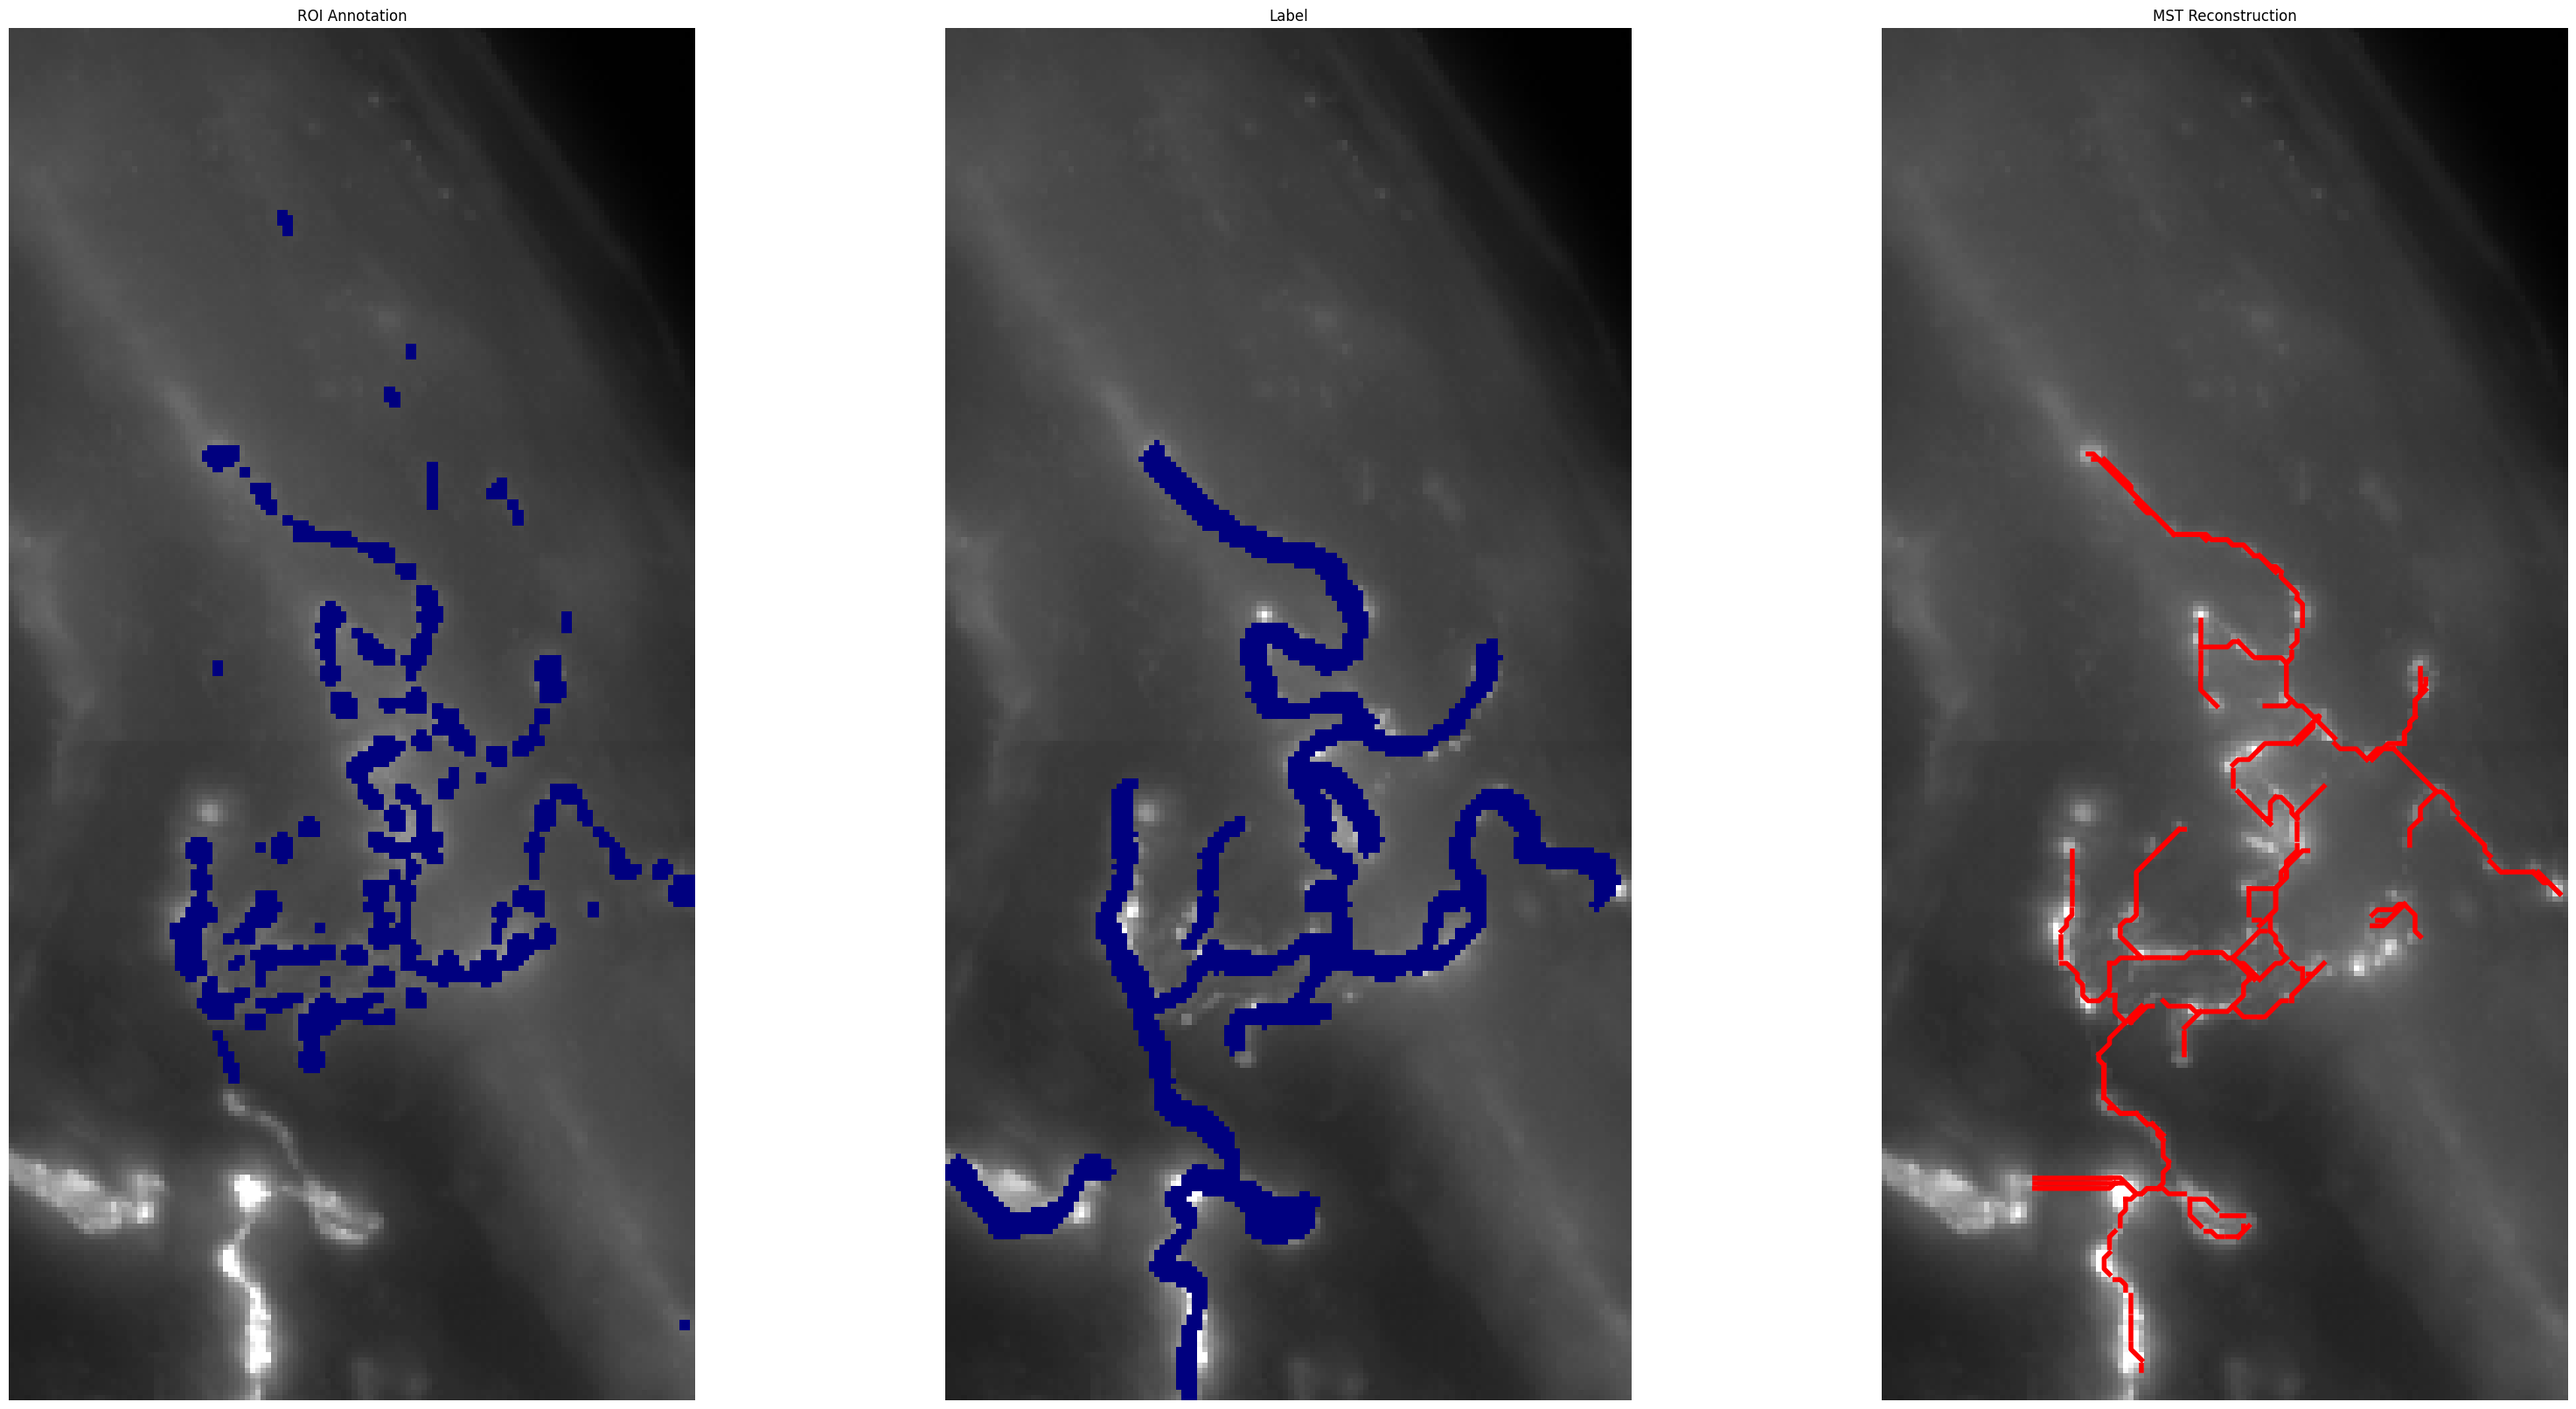

In [6]:
import matplotlib.pyplot as plt

_, ax = plt.subplots(1, 3, figsize=(32, 16), constrained_layout=True)

annotation_ax = ax[0]
annotation_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
annotation_ax.imshow(np.ma.masked_where(annotation_img==0,annotation_img)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='jet', alpha=1)

annotation_ax.set_title("ROI Annotation")
annotation_ax.axis('off')

label_ax = ax[1]
label_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
label_ax.imshow(np.ma.masked_where(label_img==0, label_img)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='jet', alpha=1)
label_ax.set_title("Label")
label_ax.axis('off')


tree_ax = ax[2]
tree_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
# Draw edges
for u, v, data in result.mst_forest.edges(data=True):
    # Nodes are expected to be (y, x) tuples from global topology
    y1, x1 = u
    y2, x2 = v

    pt1 = (int(x1), int(y1))
    pt2 = (int(x2), int(y2))

    # If edge data has 'path', draw the full path
    if "path" in data and data["path"]:
            path_points = data["path"]
            # Draw path segments
            py = []
            px = []

            for y_i, x_i in path_points:
                if y_i < ROI_Y or y_i >= ROI_Y + ROI_H or x_i < ROI_X or x_i >= ROI_X + ROI_W:
                    continue
                py.append(y_i - ROI_Y)
                px.append(x_i - ROI_X)

                # py1, px1 = path_points[i]
                # py2, px2 = path_points[i + 1]
                # p1 = (int(px1), int(py1))
                # p2 = (int(px2), int(py2))
            tree_ax.plot(px, py, color='red', alpha=1, linewidth=4)
tree_ax.set_title("MST Reconstruction")
tree_ax.axis('off')

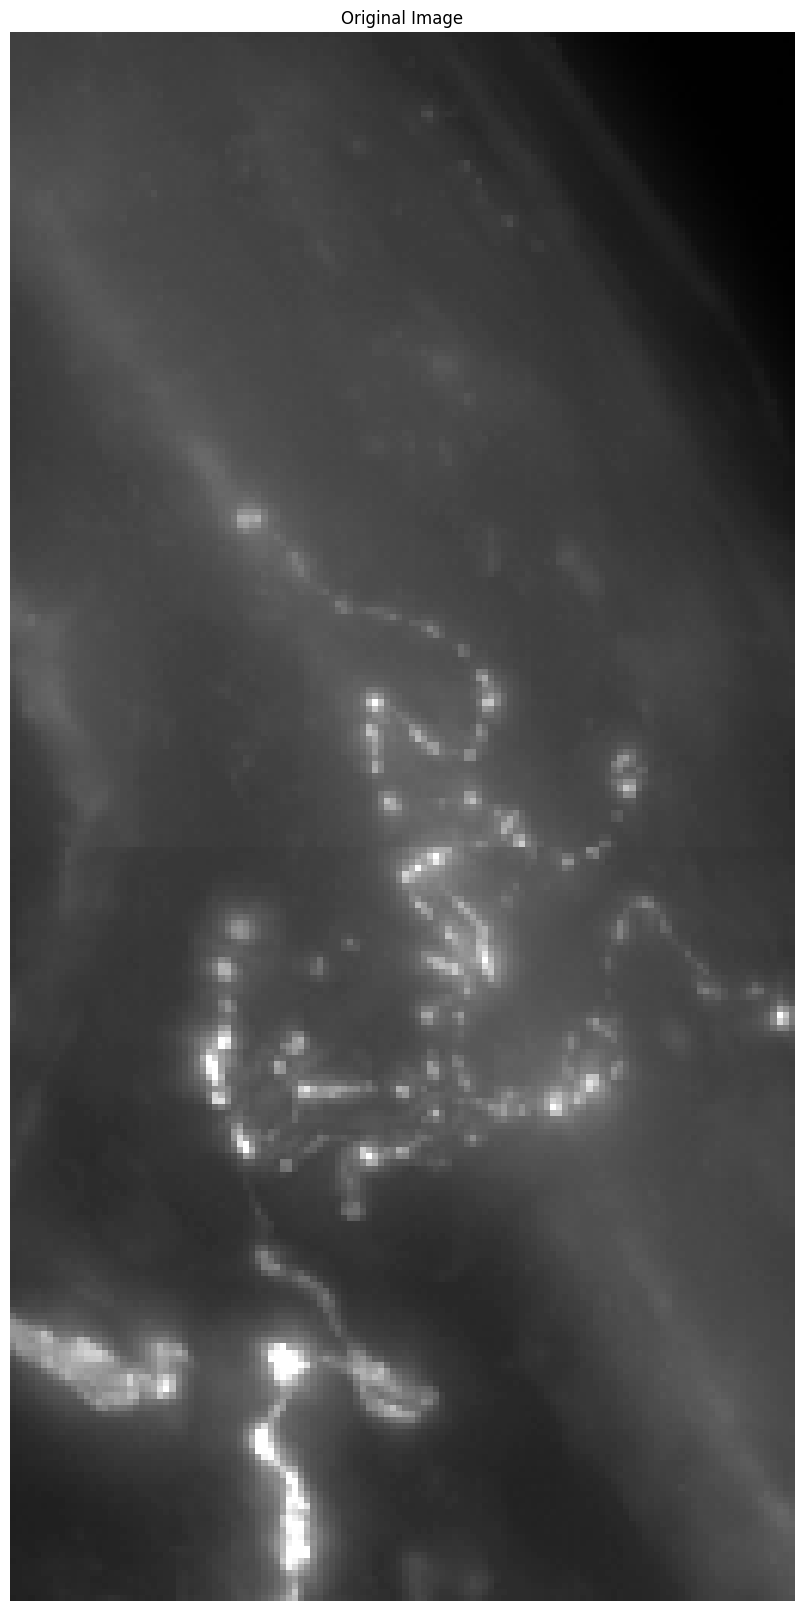

In [7]:
_, ax = plt.subplots(1, 1, figsize=(32, 16), constrained_layout=True)
ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
ax.set_title("Original Image")
ax.axis('off')
plt.show()